In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Embedding, Bidirectional, LSTM, Conv1D
from tensorflow.keras.layers import Input, Dropout, SpatialDropout1D
import tensorflow_datasets as tfds

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import re

%matplotlib inline

2026-03-07 01:21:25.049344: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-07 01:21:25.049464: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-07 01:21:25.184700: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
df = pd.read_csv('/kaggle/input/sentiment140/training.1600000.processed.noemoticon.csv', header = None,
                encoding='latin')

In [4]:
df.head(10)

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?


In [5]:
df.columns = ['sentiment','id','date','query','user_id','text']
df.head(10)

,sentiment,id,date,query,user_id,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?


In [6]:
df.drop(['id','date','query','user_id'], axis=1, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   sentiment  1600000 non-null  int64 
 1   text       1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB


In [8]:
df.sentiment.unique()

array([0, 4])

In [9]:
def label_decoder(label):
    to_sentiment = {0:'Negative',4:'Positive'}
    return to_sentiment[label]


label_decoder(4)
    

'Positive'

In [10]:
df.sentiment= df.sentiment.apply(label_decoder)
df.head(10)

,sentiment,text
0,Negative,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,Negative,is upset that he can't update his Facebook by ...
2,Negative,@Kenichan I dived many times for the ball. Man...
3,Negative,my whole body feels itchy and like its on fire
4,Negative,"@nationwideclass no, it's not behaving at all...."
5,Negative,@Kwesidei not the whole crew
6,Negative,Need a hug
7,Negative,@LOLTrish hey long time no see! Yes.. Rains a...
8,Negative,@Tatiana_K nope they didn't have it
9,Negative,@twittera que me muera ?


<Axes: xlabel='sentiment', ylabel='count'>

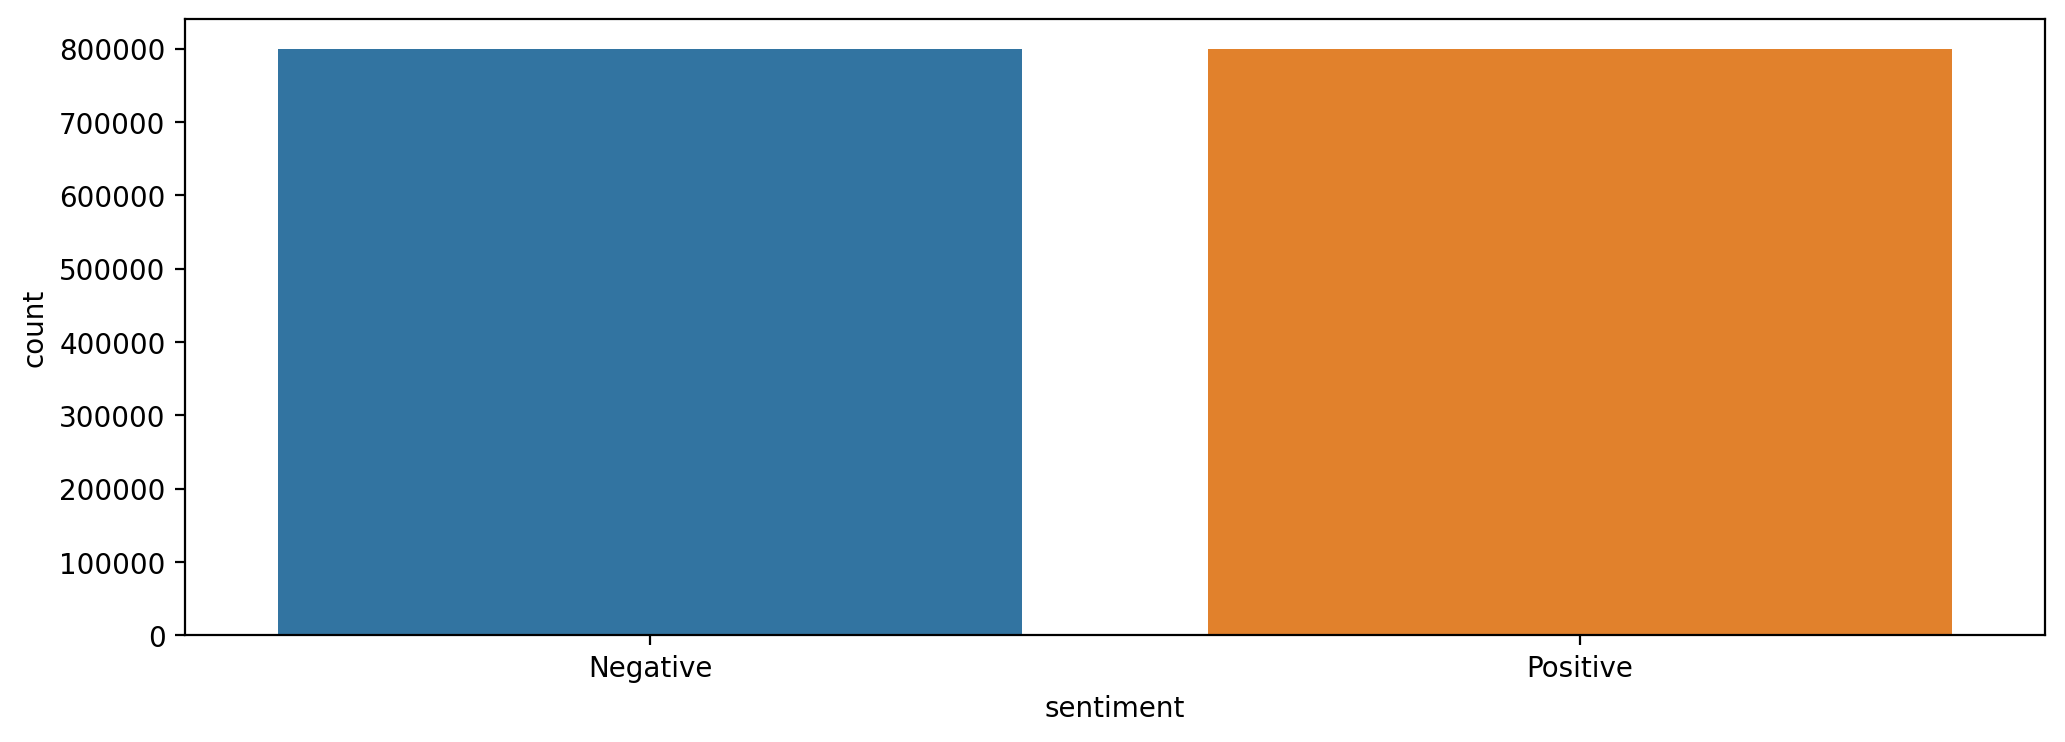

In [11]:
plt.figure(figsize=(12,4), dpi=200)
sns.countplot(x='sentiment', data = df)

In [12]:
df.sentiment.value_counts()

sentiment
Negative    800000
Positive    800000
Name: count, dtype: int64

In [13]:
text_cleaning_re = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"
s = "@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"
s = re.sub(text_cleaning_re, ' ', str(s).lower()).strip()
s

'awww that s a bummer you shoulda got david carr of third day to do it d'

In [14]:
stop_words = stopwords.words('english')
stop_words

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [15]:
# This function cleans and normalizes raw tweet text for NLP/sentiment analysis.
def preprocess(text, stem = False):
    text_cleaning_re = "@\S+|https?:\S+|http?:\S|[^A-Za-z0-9]+"
    text = re.sub(text_cleaning_re, ' ', str(text).lower()).strip()
    tokens = []
    
    for word in text.split():
        if word not in stop_words:
            if stem:
                tokens.append(stemmer.stem(word))
            else:
                tokens.append(word)
                
    return ' '.join(tokens)

s = "@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D"
preprocess(s)

'awww bummer shoulda got david carr third day'

In [16]:
df.text = df.text.apply(preprocess)
df.head(10)

,sentiment,text
0,Negative,awww bummer shoulda got david carr third day
1,Negative,upset update facebook texting might cry result...
2,Negative,dived many times ball managed save 50 rest go ...
3,Negative,whole body feels itchy like fire
4,Negative,behaving mad see
5,Negative,whole crew
6,Negative,need hug
7,Negative,hey long time see yes rains bit bit lol fine t...
8,Negative,nope
9,Negative,que muera


In [18]:
train_data, test_data = train_test_split(df, test_size=0.2, 
                                        random_state=5)

print('Size of training data :',len(train_data))
print('Size of Testing data :',len(test_data))



Size of training data : 1280000
Size of Testing data : 320000


In [19]:
train_data.head()

,sentiment,text
887460,Positive,ahaha honestly im even tired suprise woke sooo...
545899,Negative,wtf goldfish hate keep dying poor
835785,Positive,serious finish things
277841,Negative,come think one one tanga ako
1124354,Positive,started following mind direct messaging tell know


In [20]:
test_data.head()

,sentiment,text
1425895,Positive,back excellent concert gardiner street gospel ...
1153784,Positive,aww gi worry vote non stop coz love much
1424137,Positive,watching fatafeat
82854,Negative,lol please
1271893,Positive,ok


In [21]:
MAX_WORDS = 100000 # vocabulary size — top 100k words tracked
MAX_SEQ_LENGTH = 30 # every review will be exactly 30 numbers long

In [22]:
# Words are ranked by frequency — the most common word = 1, second most common = 2, etc.
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_data.text)

In [24]:
# Find out how many unique words exist in your tweets.
word_index = tokenizer.word_index
vocab_size = len(word_index)
print('vocab size : ', vocab_size)

vocab size :  290739


In [25]:
len(word_index)

290739

In [26]:
# train_sequences = tokenizer.texts_to_sequences(train_data.text)
# test_sequences = tokenizer.texts_to_sequences(test_data.text)

x_train=pad_sequences(tokenizer.texts_to_sequences(train_data.text), maxlen=MAX_SEQ_LENGTH)
x_test = pad_sequences(tokenizer.texts_to_sequences(test_data.text),maxlen=MAX_SEQ_LENGTH)

In [27]:
print('Training data shape :', x_train.shape)
print('Testing data shape :', x_test.shape)

Training data shape : (1280000, 30)
Testing data shape : (320000, 30)


In [28]:
# Converts text sentiment labels into numbers the model can train on.
encoder = LabelEncoder()
encoder.fit(train_data.sentiment.to_list())

y_train = encoder.transform(train_data.sentiment.to_list())
y_test = encoder.transform(test_data.sentiment.to_list())

y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)


print('Training labels shape :', y_train.shape)
print('Testing labels shape :', y_test.shape)

Training labels shape : (1280000, 1)
Testing labels shape : (320000, 1)


In [29]:
print(x_test)

[[     0      0      0 ...  16833     39     45]
 [     0      0      0 ...    986     10     32]
 [     0      0      0 ...      0     62 238197]
 ...
 [     0      0      0 ...  33652  30775    105]
 [     0      0      0 ...      1    103   4691]
 [     0      0      0 ...    188     95   3218]]


### Using glove pre trained embeddings

Think of GloVe as a pre-filled dictionary where instead of definitions, every word has a GPS coordinate. Words with similar meanings live close together on the map. Your model uses this map instead of building one from scratch.

Why Use It for Twitter Analysis?
Instead of training word meanings from scratch, GloVe comes pre-trained on billions of words from the internet — so it already knows:

"happy" and "joyful" are similar
"hate" and "love" are opposite

In [30]:
!wget http://nlp.stanford.edu/data/glove.6B.zip


/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


--2026-03-07 01:27:23--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-07 01:27:23--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-07 01:27:23--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: 'glove.6B.zip'

glov

In [31]:
GLOVE_EMB = '/kaggle/working/glove.6B.300d.txt'

In [32]:
# Overall: Loads the GloVe file into a Python dictionary for quick word lookup.
embedding_index = {}

f = open(GLOVE_EMB)
for line in f:
    values = line.split()
    word = values[0]
    vector = np.asarray(values[1:],dtype='float')
    embedding_index[word]=vector
    
f.close()

    
    
    


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/glove.6B.300d.txt'

In [ ]:
len(embedding_index)

In [ ]:
print(list(embedding_index.items())[1000])

Imagine a blank notebook with one page per word. You go through each word, look it up in the GloVe dictionary, and copy its meaning onto that page. If the word doesn't exist in GloVe, the page stays blank (zeros).

In [33]:
EMBEDDING_DIM =300
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

for word,token in word_index.items():
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[token] = embedding_vector
    
    

In [34]:
# Creates the first layer of your neural network that converts word tokens into meaningful vectors.embedding_matrix[0]

In [35]:


embedding_layer = Embedding(vocab_size, # how many words exist in our vocabulary
                           EMBEDDING_DIM,  # each word = 300 numbers
                           weights=[embedding_matrix], # use OUR pre-built GloVe table
                           input_length = MAX_SEQ_LENGTH, # every tweet is same fixed length
                           trainable = False) # don't change GloVe values during training

/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


```
Tweet Text
    ↓
Embedding Layer      → converts words to numbers
    ↓
SpatialDropout       → randomly ignores some words
    ↓
Conv1D               → finds patterns in words
    ↓
Bidirectional LSTM   → understands context
    ↓
Dense + Dropout      → thinks deeper
    ↓
Output               → POSITIVE or NEGATIVE (0 or 1)
```

Example of model.add(Bidirectional(LSTM(64, dropout=0.2))

Tweet: "this movie was not bad at all"

Forward LSTM:
"this movie was not bad..."  
→ sees "not bad" in order 

Backward LSTM:
"all at bad not was movie this"
→ sees "bad not" → confirms negation 

Combined → correctly predicts POSITIVE

In [36]:
model = tf.keras.models.Sequential()
model.add(embedding_layer)
model.add(SpatialDropout1D(0.2))
model.add(Conv1D(64, 5, activation='relu'))
model.add(Bidirectional(LSTM(64, dropout=0.2))) #dropout=0.2 applies recurrent dropout to prevent overfitting
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │    87,221,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │   0 (unbuilt) │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,221,700 (332.72 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 87,221,700 (332.72 MB)

In [37]:
LR = 0.0001
BATCH_SIZE = 1024
EPOCHS = 40

In [38]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=LR),
             loss = 'binary_crossentropy',
             metrics=['accuracy'])

In [39]:
history = model.fit(x_train,
                    y_train,
                    validation_data = (x_test, y_test),
                    batch_size = BATCH_SIZE,
                    epochs = EPOCHS)

Epoch 1/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.5002 - loss: 0.6931 - val_accuracy: 0.4993 - val_loss: 0.6931
Epoch 2/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.5001 - loss: 0.6931 - val_accuracy: 0.4993 - val_loss: 0.6931
Epoch 3/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.4997 - loss: 0.6931 - val_accuracy: 0.4993 - val_loss: 0.6931
Epoch 4/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.4993 - loss: 0.6931 - val_accuracy: 0.4993 - val_loss: 0.6931
Epoch 5/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.4994 - loss: 0.6931 - val_accuracy: 0.4993 - val_loss: 0.6931
Epoch 6/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.5002 - loss: 0.6931 - val_accuracy: 0.4993 - val_loss: 0.6931
Epoch 7/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.4993 - loss: 0.6931 - val_accuracy: 0.4993 - val_loss: 0.6931
Epoch 8/40
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.4999 -

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [40]:
df.sentiment.to_list()[:5]



['Negative', 'Negative', 'Negative', 'Negative', 'Negative']

In [41]:
def predict_sentiment(x):
    probs = model.predict(x)
    for prob in probs:
        if prob > 0.5:
            print('Positive')
        else:
            print('Negative')
            
predict_sentiment(x_train[0:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
Positive
Positive
Positive
Positive
Positive
Positive
Positive
Positive
Positive
Positive


In [42]:
def decode_sentiment(prob):
    return 'Positive' if prob > 0.5 else 'Negative'
    
test_probs = model.predict(x_test)
pred_test = [decode_sentiment(prob) for prob in test_probs]


10000/10000 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step


In [43]:
def create_seq(text):
#     text = preprocess(text)
    seq = pad_sequences(tokenizer.texts_to_sequences([text]),maxlen= MAX_SEQ_LENGTH)
    return seq

In [44]:
text = 'this video should bad be taken down'
seq = create_seq(text)

In [59]:
predict_sentiment(seq)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Negative
